# Indie Studio Ads Optimizer: Predicting Premium Upgrade & Total Spend


## 1. Data Overview
Tujuan : Melihat dan mengenalkan data.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("indie_studio_players.csv")
df.head()

,user_id,days_active,avg_session_time,community_engagement,total_spend,is_premium
0,1,137,228,73,365853,0
1,2,316,146,71,362463,1
2,3,112,128,44,259611,0
3,4,134,112,79,259588,0
4,5,222,45,7,144494,0


In [35]:
df.tail()

,user_id,days_active,avg_session_time,community_engagement,total_spend,is_premium
995,996,102,191,23,265288,0
996,997,69,58,50,87808,0
997,998,286,81,72,291620,1
998,999,264,69,85,228668,1
999,1000,55,112,50,208741,0


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               1000 non-null   int64
 1   days_active           1000 non-null   int64
 2   avg_session_time      1000 non-null   int64
 3   community_engagement  1000 non-null   int64
 4   total_spend           1000 non-null   int64
 5   is_premium            1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


In [37]:
df.isnull().sum()

user_id                 0
days_active             0
avg_session_time        0
community_engagement    0
total_spend             0
is_premium              0
dtype: int64

Keterangan : Data bersih dan siap di analisis.

## 2. Descriptive Statistics
Tujuan: Memahami karakter umum data.

In [38]:
df.mean()

user_id                    500.500
days_active                177.673
avg_session_time           118.858
community_engagement        49.518
total_spend             289673.572
is_premium                   0.291
dtype: float64

In [39]:
df.median()

user_id                    500.5
days_active                177.0
avg_session_time           118.0
community_engagement        48.0
total_spend             265084.5
is_premium                   0.0
dtype: float64

Insight :
- days_active = Rata-rata player aktif di angka 178 hari.
- avg_session_time = Mayoritas player punya waktu bermain hampir 2 jam setiap hari.
- community_engagement = Kebanyakan player tidak terlalu aktif di komunitas, angka engagement hanya tercatat tidak lebih dari 50.
- total_spend = Pengeluaran player untuk game mayoritas berkisar di angka 265-290 ribu rupiah.

## 3. Data Distribution
Tujuan : Memvisualisasikan distribusi data.

[Text(0, 0, '709'), Text(0, 0, '291')]

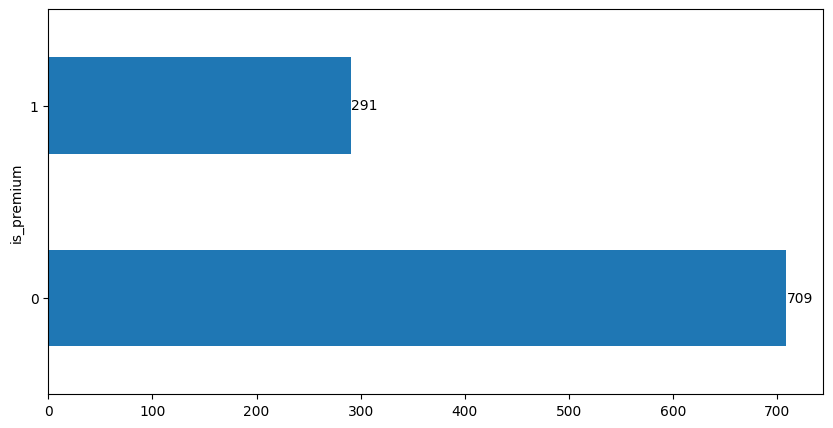

In [40]:
ax = df["is_premium"].value_counts().plot(kind="barh", figsize=(10, 5))
ax.bar_label(ax.containers[0])


Insight : Game didominasi oleh player non premium (free-to-play).

<Axes: ylabel='Frequency'>

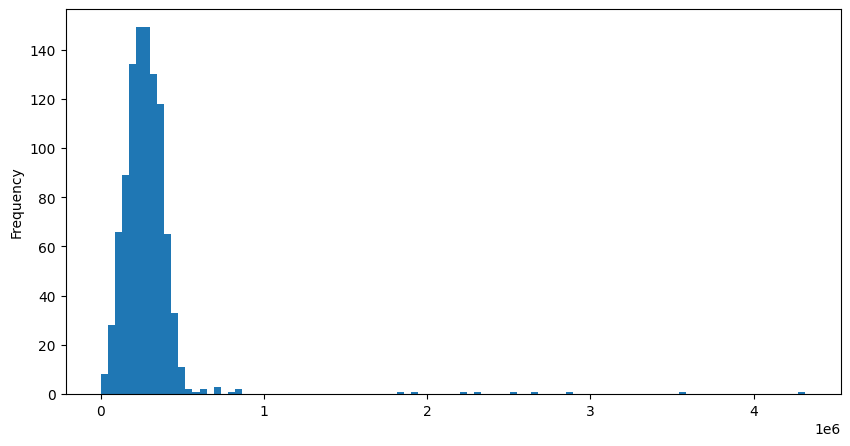

In [41]:
df["total_spend"].plot(kind="hist", bins=100, figsize=(10, 5))

Insight : Distribusi total spend menunjukkan dominasi pengeluaran player dibawah angka 500000 (dalam rupiah), meski dalam kejadian langka terdapat pengeluaran besar hingga lebih dari 4 juta rupiah.

## 4. Correlation Analysis
Tujuan: Melihat hubungan antar variabel.

<Axes: >

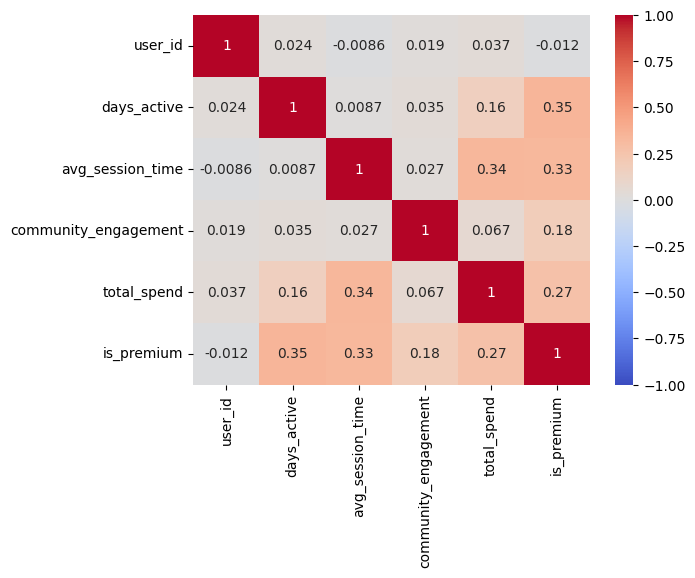

In [42]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

Insight:
- Variabel `is_premium` mempunyai korelasi paling kuat dengan `days_active` diikuti dengan `avg_session_time`. Hal ini menandakan bahwa peningkatan kemungkinan player akan premium terjadi paling tinggi atas pengaruh jumlah hari aktif dan waktu bermain player. Semakin panjang waktu bermain dan semakin banyak hari aktif, semakin tinggi pula kemungkinan player akan premium. Hal ini diikuti oleh kekuatan korelasi `is_premium` dengan `total_spend` yang juga cukup tinggi, menjadi dasar pada kesimpulan bahwa pengeluaran player mempengaruhi  tingkat kemungkinan premium player pada game tersebut. 
- Selain itu, terdapat korelasi cukup tinggi antara `total_spend` dengan `avg_session_time`. Hal ini menjadi pendukung bahwa kemungkinan player akan mengeluarkan uang untuk pembelian jika player tersebut suka menghabiskan waktu lama bermain game tersebut.

## 5. Premium vs Non-premium Player
Tujuan: Membandingkan perilaku player premium dan non-premium.

In [43]:
comparison_mean = df.groupby("is_premium").mean(numeric_only=True)
print(comparison_mean)

               user_id  days_active  avg_session_time  community_engagement  \
is_premium                                                                    
0           502.727786   154.716502        104.409027             46.260931   
1           495.072165   233.604811        154.061856             57.453608   

              total_spend  
is_premium                 
0           244320.121298  
1           400173.903780  


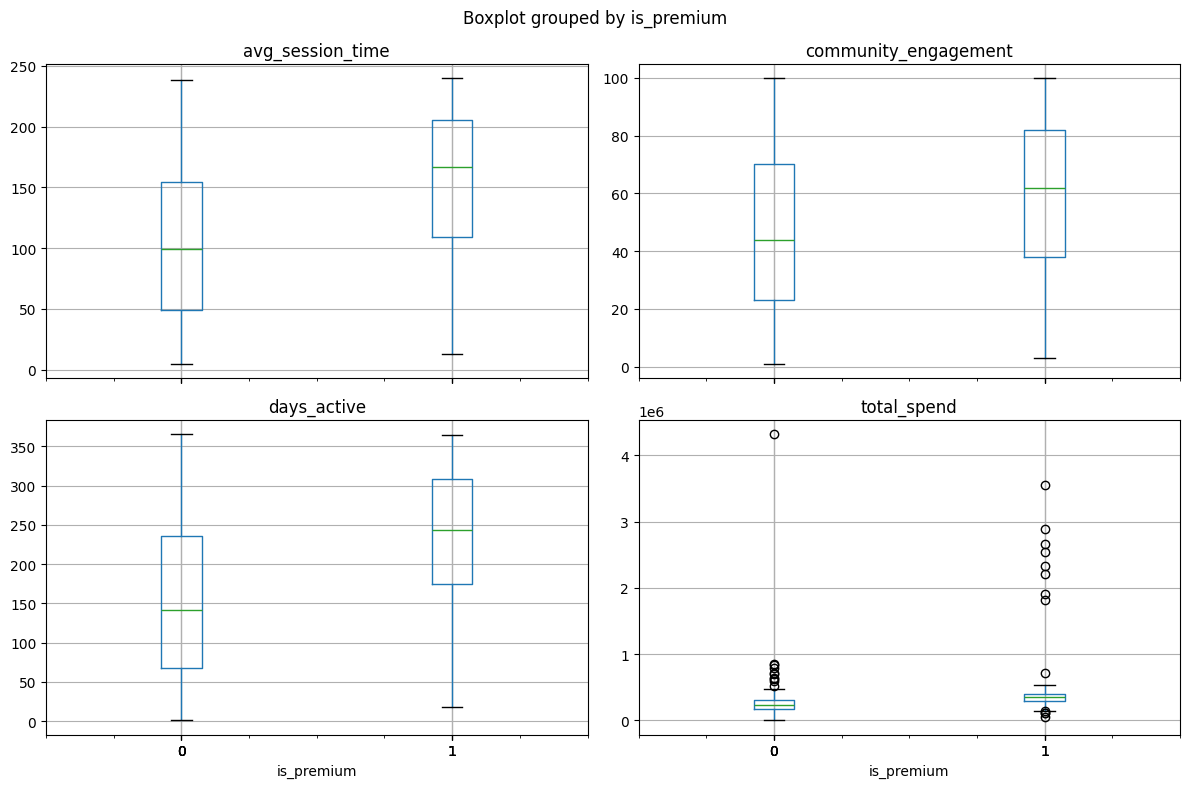

In [44]:
kolom_tujuan = ['avg_session_time', 'community_engagement', 'days_active', 'total_spend']
df.boxplot(column=kolom_tujuan, by='is_premium', figsize=(12, 8), sharey=False)


plt.tight_layout()

Insight:
- Premium mendorong retensi & keaktifan, pengguna premium (1) jauh lebih loyal dan betah. Nilai tengah (median) untuk waktu sesi (`avg_session_time`) dan jumlah hari aktif (`days_active`) mereka meningkat drastis dibandingkan pengguna biasa (0).
- Komunitas lebih hidup, pengguna premium menunjukkan interaksi yang lebih solid. Lebih dari setengah populasi premium memiliki skor community_engagement di atas nilai 60.
- Meski pengguna premium rata-rata belanja sedikit lebih tinggi, pengeluaran terbesar secara individu justru datang dari pengguna non-premium (0) dengan nilai ekstrem mencapai angka ~4.3 juta.

## 6. Scatterplots

Tujuan: Melihat pola visual data.

<Axes: xlabel='avg_session_time', ylabel='total_spend'>

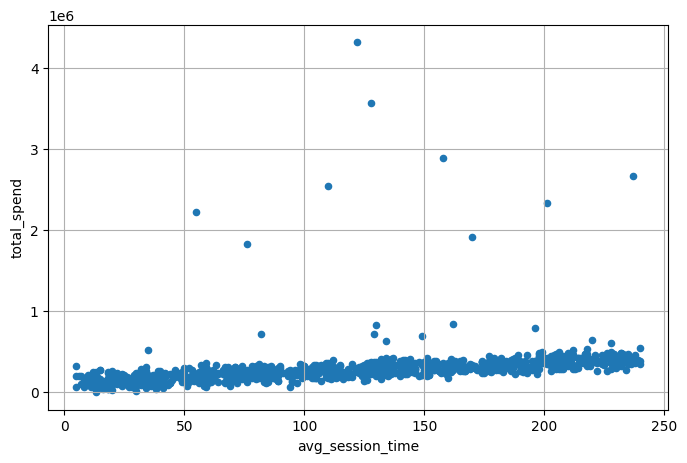

In [45]:
df.plot.scatter(x='avg_session_time', y='total_spend', grid=True, figsize=(8, 5))

Insight:
-  Mayoritas pengguna membentuk tren linier yang padat di bagian bawah; semakin lama waktu sesi (`avg_session_time`), semakin tinggi batas minimal total pengeluaran mereka (`total_spend`).
- Terdapat beberapa pembelanja ekstrem (outliers) bernilai jutaan di bagian atas grafik, yang uniknya melakukan transaksi besar tanpa harus memiliki waktu sesi yang paling lama (terkonsentrasi di durasi 110–130 menit).

<Axes: xlabel='days_active', ylabel='total_spend'>

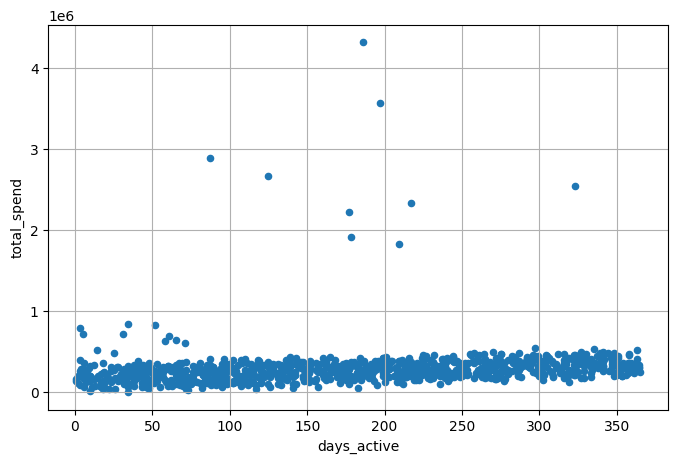

In [46]:
df.plot.scatter(x='days_active', y='total_spend', grid=True, figsize=(8, 5))

Insight:
- Terjadi tren kenaikan yang sangat landai di bagian bawah data. Pengguna yang aktif mendekati satu tahun (300–360 hari) memiliki batas bawah pengeluaran yang lebih stabil di atas nol, dibandingkan pengguna baru (0–50 hari).
- Sama seperti grafik sebelumnya, mayoritas mutlak pengguna menumpuk pada pengeluaran rendah di bawah 500 ribu, terlepas dari berapa lama mereka telah aktif di aplikasi.
- Pembelanja ekstrem dengan nilai jutaan (outliers) justru tidak didominasi oleh pengguna yang paling loyal (aktif >300 hari). Pengguna dengan transaksi tertinggi (~4.3 juta) berada di kisaran keaktifan menengah (sekitar 180 hari).

## 7. Preprocessing
Tujuan : Menyiapkan data.

### 7.1 Features and Target

In [47]:
features = [
    "days_active",
    "avg_session_time",
    "community_engagement",
]

target = "total_spend"

x = df[features]
y = df[target]

Insight:
- Tiga variabel fitur menjadi data input yang akan dipelajari model untuk menjadi target.

### 7.2 Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 7.3 Scaling

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


## 8. Linear Regression
Tujuan : Training.

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 8.1 Prediction

In [51]:
y_pred = model.predict(x_test_scaled)


### 8.2 Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.0f}")
print(f"MSE  : {mse:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"R²   : {r2:.3f}")

MAE  : 63,927
MSE  : 75,478,113,785
RMSE : 274,733
R²   : 0.137


### 8.3 Visualization

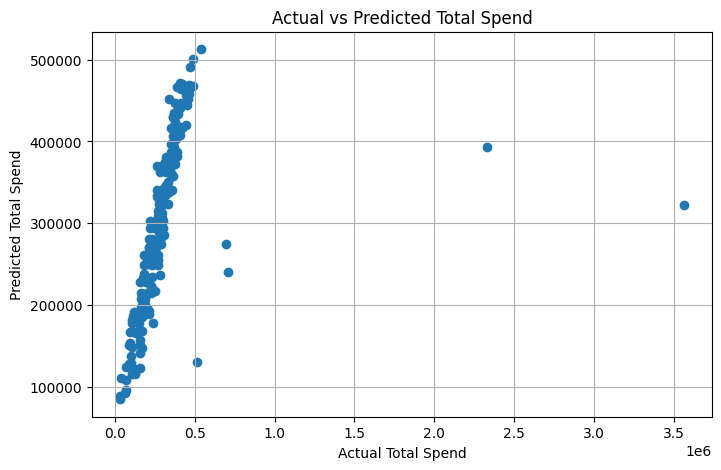

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted Total Spend")

plt.title("Actual vs Predicted Total Spend")

plt.grid(True)

plt.show()

### 8.4 Weights / Coefficients

In [54]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,days_active,41802.174425
1,avg_session_time,86355.802277
2,community_engagement,10928.688591


Insight: 
- Model Linear Regression cukup mampu menangkap pola umum pengeluaran pemain biasa, namun kesulitan memprediksi pemain dengan pengeluaran ekstrem (whales).
- Hal ini terlihat dari rendahnya nilai R² dan adanya beberapa titik outlier besar pada grafik Actual vs Predicted.
- Karena Linear Regression berusaha mencari garis rata-rata terbaik, model cenderung mengabaikan sebagian kecil pemain dengan spending sangat tinggi.